# Verification: Scaffolded MAPK cascade (Kocieniewski et al., 2012)

This notebook verifies the curated `scaffolded_mapk_cascade_kocieniewski2012`
collection (the **Scaff-22** primary model and its **Scaff-11**
mono-phosphorylation variant) from Kocieniewski P, Faeder JR, Lipniacki T
(2012), *The interplay of double phosphorylation and scaffolding in MAPK
pathways*, J Theor Biol 295:116-124, doi:10.1016/j.jtbi.2011.11.014.

Two independent levels of verification are performed:

1. **Model-specification** — BioNetGen generates the reaction network and
   integrates the mass-action ODEs with CVODE. We independently parse the
   generated `.net`, rebuild the ODE right-hand side in NumPy, integrate it
   with SciPy (`solve_ivp`), and compare. We also check the generated
   species/reaction counts against the paper, verify exact conservation of
   total MAP3K/MAP2K/MAPK/scaffold, and check the active-MAP3K steady state
   against the analytic value `S*Atot/(S+u)`.
2. **Reported-data** — we reproduce **Fig. 2** (steady-state response *R* =
   active unbound MAPK vs total scaffold `Stot`, at `S = 1 /s`) for both
   models and compare against the digitized Fig. 2 curves.

**Plot convention:** lines = BioNetGen (CVODE / `parameter_scan`), open
markers = independent SciPy ODE, thick gray = digitized Fig. 2.

> Note on reaction counts: BioNetGen 2.9.3 generates the same *species* set
> as the paper (85 for Scaff-22, 33 for Scaff-11) but fewer unidirectional
> *reactions* (487 vs 527; 127 vs 145). The species set is identical and mass
> is conserved, so the difference reflects reaction-deduplication/counting
> changes across BioNetGen versions, not a change in dynamics.


In [1]:
import os, shutil, subprocess, tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.sparse import csc_matrix

BASE_STEM = "scaffolded_mapk_cascade_kocieniewski2012"
S11_STEM = "scaffolded_mapk_cascade_kocieniewski2012_scaff11"


def find_model_dir():
    for c in (Path.cwd(), Path.cwd() / "models" / BASE_STEM,
              Path.cwd().parent / "models" / BASE_STEM):
        if (c / f"{BASE_STEM}.bngl").exists():
            return c.resolve()
    raise FileNotFoundError("Could not locate the model directory")


MODEL_DIR = find_model_dir()
os.chdir(MODEL_DIR)
REF_DIR = MODEL_DIR / "reference"
PNG_FILE = MODEL_DIR / "verify_kocieniewski2012.png"

# Table 1 parameters used for the analytic active-MAP3K check
S_SIGNAL, ATOT, U = 1.0, 1e5, 0.1
print("Model directory:", MODEL_DIR)

Model directory: /Users/l119605/Code/BNGL-Models/models/scaffolded_mapk_cascade_kocieniewski2012


In [2]:
def bionetgen_command(model_name):
    env_bng2 = os.environ.get("BNG2_PL")
    if env_bng2 and Path(env_bng2).expanduser().is_file():
        return ["perl", str(Path(env_bng2).expanduser()), model_name]
    local = Path.home() / "Simulations" / "BioNetGen-2.9.3" / "BNG2.pl"
    if local.is_file():
        return ["perl", str(local), model_name]
    cli = shutil.which("bionetgen")
    if cli:
        return [cli, "run", "-i", model_name]
    raise FileNotFoundError("BioNetGen not found. Set BNG2_PL or install bionetgen.")


def load_gdat(path):
    with open(path) as fh:
        header = fh.readline().lstrip("#").split()
    return header, np.atleast_2d(np.loadtxt(path))


def load_scan(path):
    with open(path) as fh:
        header = fh.readline().lstrip("#").split()
    return header, np.atleast_2d(np.loadtxt(path))


def strip_scan(bngl_text):
    """Keep the relaxation protocol only; drop the parameter_scan protocol."""
    idx = bngl_text.index("  # Scaffold prozone scan")
    return bngl_text[:idx].rstrip() + "\nend actions\n"


def run_relaxation(stem):
    """Run only the ODE relaxation protocol in a temp dir; return net + gdat."""
    bngl = (MODEL_DIR / f"{stem}.bngl").read_text()
    tmp = tempfile.mkdtemp(prefix="kocz_bng_")
    run_bngl = Path(tmp) / f"{stem}.bngl"
    run_bngl.write_text(strip_scan(bngl))
    res = subprocess.run(bionetgen_command(run_bngl.name), cwd=tmp,
                         capture_output=True, text=True, timeout=300)
    assert res.returncode == 0, res.stderr or res.stdout[-2000:]
    net = Path(tmp) / f"{stem}.net"
    hdr, data = load_gdat(Path(tmp) / f"{stem}_ode.gdat")
    return str(net), hdr, data

In [3]:
def parse_net(path):
    """Parse a BNG .net into initial state, stoichiometry, rate constants,
    up-to-bimolecular reactant indices, and observable (group) weights."""
    params, y0, patterns, reactions, groups = {}, [], [], [], []
    block = None
    for raw in open(path):
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        if line.startswith("begin "):
            block = line.split()[1]; continue
        if line.startswith("end "):
            block = None; continue
        body = line.split("#", 1)[0].strip()
        if not body:
            continue
        p = body.split()
        if block == "parameters":
            params[p[1]] = float(eval("".join(p[2:]), {"__builtins__": {}}, params))
        elif block == "species":
            patterns.append(p[1])
            y0.append(float(eval("".join(p[2:]), {"__builtins__": {}}, params)))
        elif block == "reactions":
            r = [int(x) - 1 for x in p[1].split(",") if x != "0"]
            pr = [int(x) - 1 for x in p[2].split(",") if x != "0"]
            k = float(eval("".join(p[3:]), {"__builtins__": {}}, params))
            reactions.append((r, pr, k))
        elif block == "groups":
            g = body.split(None, 2)
            members = [] if len(g) < 3 else [
                (int(t.split("*")[-1]) - 1, float(t.split("*")[0]) if "*" in t else 1.0)
                for t in g[2].split(",") if t]
            groups.append((g[1], members))
    n, m = len(y0), len(reactions)
    rows, cols, vals = [], [], []
    kk = np.empty(m); ra = np.zeros(m, int); rb = np.full(m, -1)
    for j, (r, pr, k) in enumerate(reactions):
        assert 1 <= len(r) <= 2, "only uni/bimolecular reactions expected"
        kk[j] = k; ra[j] = r[0]
        if len(r) > 1:
            rb[j] = r[1]
        net_stoich = {}
        for i in r:
            net_stoich[i] = net_stoich.get(i, 0) - 1
        for i in pr:
            net_stoich[i] = net_stoich.get(i, 0) + 1
        for i, v in net_stoich.items():
            if v:
                rows.append(i); cols.append(j); vals.append(v)
    S = csc_matrix((vals, (rows, cols)), shape=(n, m))
    gnames = [g[0] for g in groups]
    G = np.zeros((len(groups), n))
    for gi, (_, members) in enumerate(groups):
        for idx, w in members:
            G[gi, idx] += w
    rb_safe = rb.copy(); rb_safe[rb < 0] = 0
    return dict(y0=np.array(y0), patterns=patterns, S=S, kk=kk, ra=ra,
                rb=rb, rb_safe=rb_safe, gnames=gnames, G=G, n=n, m=m)


def make_rhs(net):
    S, kk, ra, rb, rb_safe = net["S"], net["kk"], net["ra"], net["rb"], net["rb_safe"]
    bimol = rb >= 0
    def rhs(t, y):
        flux = kk * y[ra]
        flux[bimol] *= y[rb_safe][bimol]
        return S.dot(flux)
    return rhs


def scaff_species_index(net):
    """Free scaffold monomer: the nonzero seed species that is Scaff(...) alone."""
    for i, (pat, y) in enumerate(zip(net["patterns"], net["y0"])):
        if y > 0 and pat.startswith("Scaff(") and "." not in pat:
            return i
    raise LookupError("free Scaff species not found")

## Part 1 — Model-specification verification

Run each model's ODE relaxation in BioNetGen, then independently integrate the
parsed network in SciPy and compare. Also check species/reaction counts,
conservation laws, and the analytic active-MAP3K steady state.

In [4]:
# (species, BNG-2.9.3 reactions, paper reactions)
NET_COUNTS = {BASE_STEM: (85, 487, 527), S11_STEM: (33, 127, 145)}
runs = {}
for stem in (BASE_STEM, S11_STEM):
    net_path, hdr, bng = run_relaxation(stem)
    net = parse_net(net_path)
    t = bng[:, 0]
    sol = solve_ivp(make_rhs(net), (t[0], t[-1]), net["y0"], method="LSODA",
                    t_eval=t, rtol=1e-9, atol=1e-3)
    assert sol.success, sol.message
    obs = net["G"] @ sol.y
    max_rel = 0.0
    for gi, gname in enumerate(net["gnames"]):
        if gname in hdr:
            a, b = bng[:, hdr.index(gname)], obs[gi]
            max_rel = max(max_rel, np.max(np.abs(a - b) / np.maximum(np.abs(a), 1.0)))
    gt = {g: obs[i, -1] for i, g in enumerate(net["gnames"])}
    map3k_analytic = S_SIGNAL * ATOT / (S_SIGNAL + U)
    runs[stem] = dict(net=net, hdr=hdr, bng=bng, t=t, obs=obs, max_rel=max_rel)
    exp_sp, exp_rx, paper_rx = NET_COUNTS[stem]
    assert net["n"] == exp_sp, (net["n"], exp_sp)
    assert net["m"] == exp_rx, (net["m"], exp_rx)
    for tot, val in [("MAP3K", gt["Obs_MAP3K_tot"]), ("MAP2K", gt["Obs_MAP2K_tot"]),
                     ("MAPK", gt["Obs_MAPK_tot"]), ("Scaff", gt["Obs_Scaff_tot"])]:
        pass
    print(f"{stem}")
    print(f"  species {net['n']} (paper {exp_sp}) | reactions {net['m']} "
          f"(paper {paper_rx}; BNG 2.9.3 {exp_rx})")
    print(f"  max rel error BNG vs SciPy (all observables): {max_rel:.2e}")
    print(f"  conservation @ ss: MAP3K={gt['Obs_MAP3K_tot']:.1f} "
          f"MAP2K={gt['Obs_MAP2K_tot']:.1f} MAPK={gt['Obs_MAPK_tot']:.1f} "
          f"Scaff={gt['Obs_Scaff_tot']:.1f}")
    print(f"  MAP3K_active @ ss: {gt['Obs_MAP3K_A']:.1f} "
          f"(analytic S*Atot/(S+u)={map3k_analytic:.1f}, "
          f"{abs(gt['Obs_MAP3K_A']-map3k_analytic)/map3k_analytic*100:.3f}% diff)")
    print(f"  response Obs_R @ ss: {gt['Obs_R']:.1f}\n")

scaffolded_mapk_cascade_kocieniewski2012
  species 85 (paper 85) | reactions 487 (paper 527; BNG 2.9.3 487)
  max rel error BNG vs SciPy (all observables): 6.43e-07
  conservation @ ss: MAP3K=100000.0 MAP2K=100000.0 MAPK=500000.0 Scaff=100000.0
  MAP3K_active @ ss: 90886.5 (analytic S*Atot/(S+u)=90909.1, 0.025% diff)
  response Obs_R @ ss: 39850.9



scaffolded_mapk_cascade_kocieniewski2012_scaff11
  species 33 (paper 33) | reactions 127 (paper 145; BNG 2.9.3 127)
  max rel error BNG vs SciPy (all observables): 5.11e-07
  conservation @ ss: MAP3K=100000.0 MAP2K=100000.0 MAPK=500000.0 Scaff=100000.0
  MAP3K_active @ ss: 90886.5 (analytic S*Atot/(S+u)=90909.1, 0.025% diff)
  response Obs_R @ ss: 85051.1



## Part 2 — Reported-data verification (Fig. 2)

Reproduce the steady-state response *R* as a function of total scaffold `Stot`
at `S = 1 /s`. For the independent SciPy reproduction we reuse each parsed
network (the topology is `Stot`-independent) and simply set the free-scaffold
seed count to each `Stot` before integrating to steady state. We compare the
BioNetGen `parameter_scan` reference, the independent SciPy scan, and the
digitized Fig. 2 curves.

**Tolerance.** The reported data are thick curves plotted on a linear axis
spanning 0-10x10^4 molecules. Digitizing such curves carries an uncertainty of
order the line thickness, a few percent of full scale. We therefore accept
agreement within ~5% of full scale (10^5 molecules) on peak amplitude and on
the RMS curve distance.

In [5]:
STOT_GRID = np.logspace(1, 6, 61)
YMAX = 1e5   # Fig. 2 y-axis full scale, for %-of-full-scale tolerances
TOL_FS = 0.05


def scipy_prozone(net):
    si = scaff_species_index(net)
    ri = net["gnames"].index("Obs_R")
    out = np.empty(len(STOT_GRID))
    for j, stot in enumerate(STOT_GRID):
        y0 = net["y0"].copy(); y0[si] = stot
        sol = solve_ivp(make_rhs(net), (0.0, 2000.0), y0, method="LSODA",
                        t_eval=[2000.0], rtol=1e-9, atol=1e-3)
        assert sol.success, sol.message
        out[j] = (net["G"] @ sol.y[:, -1])[ri]
    return out


dig = {
    BASE_STEM: np.loadtxt(REF_DIR / "kocieniewski2012_fig2_scaff22_digitized.csv",
                          delimiter=",", skiprows=1),
    S11_STEM: np.loadtxt(REF_DIR / "kocieniewski2012_fig2_scaff11_digitized.csv",
                         delimiter=",", skiprows=1),
}
LABELS = {BASE_STEM: "Scaff-22", S11_STEM: "Scaff-11"}
proz = {}
for stem in (BASE_STEM, S11_STEM):
    sc = scipy_prozone(runs[stem]["net"])
    hdrs, scan = load_scan(REF_DIR / f"{stem}_scan.scan")
    bx, by = scan[:, 0], scan[:, hdrs.index("Obs_R")]
    d = dig[stem]
    model_on_dig = np.interp(np.log10(d[:, 0]), np.log10(STOT_GRID), sc)
    rms = np.sqrt(np.mean((model_on_dig - d[:, 1]) ** 2))
    peak_amp_err = abs(sc.max() - d[:, 1].max())
    proz[stem] = dict(sc=sc, bx=bx, by=by, dig=d, rms=rms, peak_amp_err=peak_amp_err)
    assert peak_amp_err < TOL_FS * YMAX, peak_amp_err
    assert rms < TOL_FS * YMAX, rms
    print(f"{LABELS[stem]}: model peak R={sc.max():.0f} at Stot={STOT_GRID[np.argmax(sc)]:.3g}; "
          f"digitized peak R={d[:,1].max():.0f} at Stot={d[np.argmax(d[:,1]),0]:.3g}")
    print(f"  peak amplitude error {peak_amp_err/YMAX*100:.2f}% FS | "
          f"RMS(model-digitized) {rms/YMAX*100:.2f}% FS  (tol {TOL_FS*100:.0f}% FS)\n")

Scaff-22: model peak R=45870 at Stot=1.78e+05; digitized peak R=45414 at Stot=1.78e+05
  peak amplitude error 0.46% FS | RMS(model-digitized) 0.20% FS  (tol 5% FS)



Scaff-11: model peak R=99273 at Stot=2.15e+05; digitized peak R=98669 at Stot=1.93e+05
  peak amplitude error 0.60% FS | RMS(model-digitized) 0.46% FS  (tol 5% FS)



## Figure

Top: ODE relaxation (BioNetGen lines, SciPy open markers). Bottom-left: Fig. 2
reproduction (digitized curves in gray, BioNetGen `parameter_scan` lines, SciPy
open markers).

Saved /Users/l119605/Code/BNGL-Models/models/scaffolded_mapk_cascade_kocieniewski2012/verify_kocieniewski2012.png


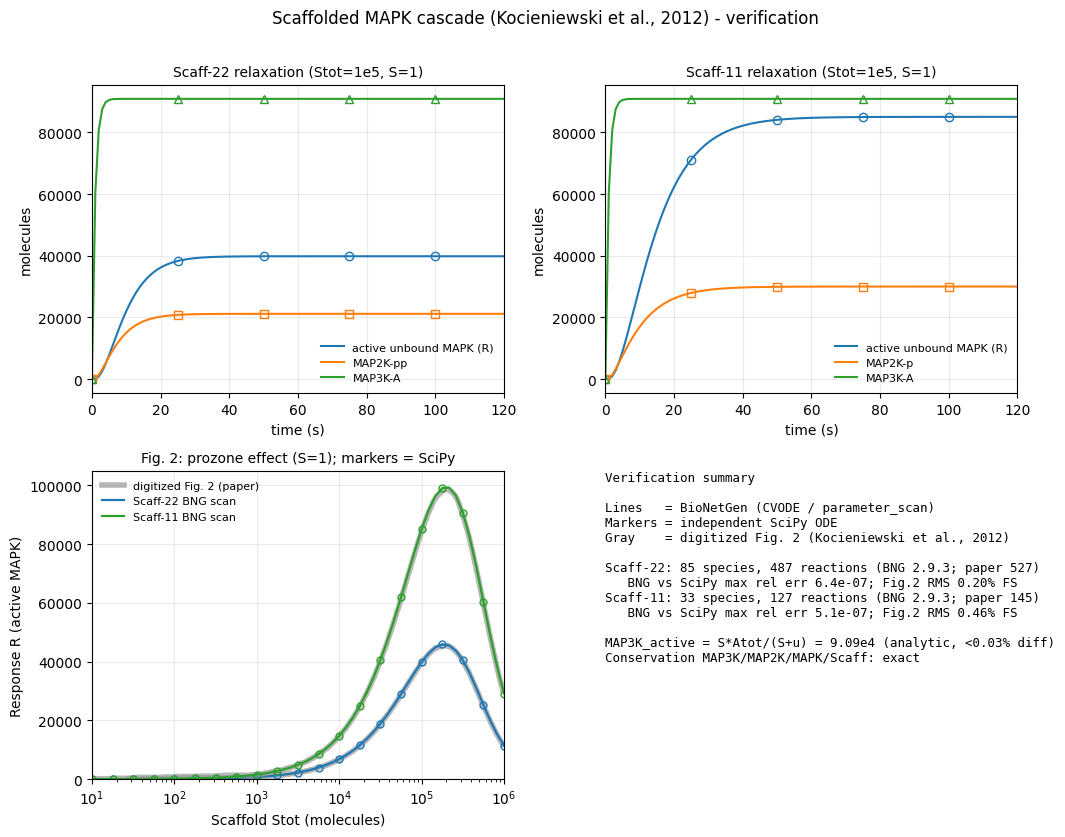

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
markers = ["o", "s", "^"]

obs_top = {
    BASE_STEM: [("Obs_R", "active unbound MAPK (R)"), ("Obs_MAP2K_pp", "MAP2K-pp"),
                ("Obs_MAP3K_A", "MAP3K-A")],
    S11_STEM: [("Obs_R", "active unbound MAPK (R)"), ("Obs_MAP2K_p", "MAP2K-p"),
               ("Obs_MAP3K_A", "MAP3K-A")],
}
for ax, stem, title in [
        (axes[0, 0], BASE_STEM, "Scaff-22 relaxation (Stot=1e5, S=1)"),
        (axes[0, 1], S11_STEM, "Scaff-11 relaxation (Stot=1e5, S=1)")]:
    r = runs[stem]
    for k, (gname, lab) in enumerate(obs_top[stem]):
        c = colors[k]
        ax.plot(r["t"], r["bng"][:, r["hdr"].index(gname)], "-", color=c, lw=1.5, label=lab)
        gi = r["net"]["gnames"].index(gname)
        ax.plot(r["t"][::25], r["obs"][gi][::25], markers[k], mfc="none", mec=c, ms=6)
    ax.set_xlim(0, 120); ax.set_xlabel("time (s)"); ax.set_ylabel("molecules")
    ax.set_title(title, fontsize=10); ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)

ax = axes[1, 0]
cmap = {BASE_STEM: colors[0], S11_STEM: colors[2]}
ax.plot([], [], color="0.6", lw=4, alpha=0.7, label="digitized Fig. 2 (paper)")
for stem in (BASE_STEM, S11_STEM):
    d, c = proz[stem], cmap[stem]
    ax.plot(d["dig"][:, 0], d["dig"][:, 1], color="0.6", lw=4, alpha=0.7)
    ax.plot(d["bx"], d["by"], "-", color=c, lw=1.6, label=f"{LABELS[stem]} BNG scan")
    ax.plot(STOT_GRID[::3], d["sc"][::3], "o", mfc="none", mec=c, ms=5)
ax.set_xscale("log"); ax.set_xlim(1e1, 1e6); ax.set_ylim(0, 1.05e5)
ax.set_xlabel("Scaffold Stot (molecules)"); ax.set_ylabel("Response R (active MAPK)")
ax.set_title("Fig. 2: prozone effect (S=1); markers = SciPy", fontsize=10)
ax.grid(alpha=0.25); ax.legend(frameon=False, fontsize=8, loc="upper left")

ax = axes[1, 1]; ax.axis("off")
lines = ["Verification summary", "",
         "Lines   = BioNetGen (CVODE / parameter_scan)",
         "Markers = independent SciPy ODE",
         "Gray    = digitized Fig. 2 (Kocieniewski et al., 2012)", ""]
for stem in (BASE_STEM, S11_STEM):
    net = runs[stem]["net"]; paper_rx = NET_COUNTS[stem][2]
    lines.append(f"{LABELS[stem]}: {net['n']} species, {net['m']} reactions "
                 f"(BNG 2.9.3; paper {paper_rx})")
    lines.append(f"   BNG vs SciPy max rel err {runs[stem]['max_rel']:.1e}; "
                 f"Fig.2 RMS {proz[stem]['rms']/YMAX*100:.2f}% FS")
lines += ["", "MAP3K_active = S*Atot/(S+u) = 9.09e4 (analytic, <0.03% diff)",
          "Conservation MAP3K/MAP2K/MAPK/Scaff: exact"]
ax.text(0.0, 1.0, "\n".join(lines), va="top", ha="left", fontsize=9, family="monospace")

fig.suptitle("Scaffolded MAPK cascade (Kocieniewski et al., 2012) - verification",
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(PNG_FILE, dpi=130)
print("Saved", PNG_FILE)
plt.show()